# % of Bike Commuters vs Bike Network Quality (Connectivity of LTS < 2 Subnetwork)

In [151]:
%%capture
pip install osmnx

In [152]:
%%capture
pip install --pre pycen==0.1.0a4

In [185]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import osmnx as ox
import networkx as nx
from pycen import acquire

plt.style.use('seaborn-v0_8')

city = "Santa Monica"
county= 'Los Angeles'
state = "California"

PLACE = "%s, %s, USA"%(city,state)
YEARS = [2014, 2019]
DATASET = "acs5"

variables = {
    "B08301_001E": "workers_total",
    "B08301_008E": "bike_commute"
}

print("Libraries imported.")

Libraries imported.


## 1. Import csv of bike quality metrics by census tract (calculated in other notebooks)

In [222]:
bike_network_quality = pd.read_csv('data/%s_network_quality_metrics.csv'%city)

## 3. Download ACS bike commute share for Berkeley tracts

We pull tract-level data for two years and compute the percentage of workers who commute by bicycle.

In [223]:
tracts_by_year = []
for year in YEARS:
    gdf = acquire.get_censhp(
        variables=variables,
        geography="tract",
        place="%s"%city,
        state="CA",
        year=year,
        dataset=DATASET,
        add_area=True
    )
    gdf.replace(-666666666, np.nan, inplace=True)
    gdf["pct_bike_%s"%year] = gdf["bike_commute"] / gdf["workers_total"] * 100
    #gdf["year"] = year
    tracts_by_year.append(gdf.to_crs("EPSG:4326"))

gdf_2014=tracts_by_year[0].reset_index()
gdf_2019=tracts_by_year[1].reset_index()

#tracts = gpd.GeoDataFrame(pd.concat(tracts_by_year, ignore_index=True), crs="EPSG:4326")
tracts = gpd.GeoDataFrame(gdf_2014)

Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2014_tract_06__07ae958225a92c0b.csv
Loading boundaries from cache...
Merging data...
Clipping to place: Berkeley
Fetching boundaries...
Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2019_tract_06__60e657f1e70e8a23.csv
Loading boundaries from cache...
Merging data...
Clipping to place: Berkeley
Fetching boundaries...


In [224]:
tracts=pd.merge(tracts,gdf_2019[['GEOID','pct_bike_2019']],on='GEOID')
tracts['pct_change']=tracts['pct_bike_2019']-tracts['pct_bike_2014']
#tracts=pd.merge(tracts,gdf_2019['pct_bike_2019'],on='')


In [225]:
tracts

,index,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry,workers_total,bike_commute,state,county,tract,area_sqkm,pct_bike_2014,pct_bike_2019,pct_change
0,11,06,001,422700,1400000US06001422700,06001422700,4227,CT,348098,0,"MULTIPOLYGON Z (((-122.25459 37.86932 0, -122....",1297.0,0.0,6,1,422700,0.355836,0.000000,0.000000,0.000000
1,12,06,001,423602,1400000US06001423602,06001423602,4236.02,CT,404545,0,"MULTIPOLYGON Z (((-122.26528 37.86427 0, -122....",2417.0,16.0,6,1,423602,0.414944,0.661978,0.000000,-0.661978
2,686,06,001,421800,1400000US06001421800,06001421800,4218,CT,528477,0,"MULTIPOLYGON Z (((-122.28327 37.88093 0, -122....",1081.0,0.0,6,1,421800,0.529614,0.000000,0.000000,0.000000
3,687,06,001,422200,1400000US06001422200,06001422200,4222,CT,675011,0,"MULTIPOLYGON Z (((-122.29422 37.87517 0, -122....",1964.0,0.0,6,1,422200,0.674020,0.000000,0.000000,0.000000
4,688,06,001,422800,1400000US06001422800,06001422800,4228,CT,408571,0,"MULTIPOLYGON Z (((-122.26599 37.86784 0, -122....",1924.0,0.0,6,1,422800,0.406699,0.000000,0.000000,0.000000
5,689,06,001,423500,1400000US06001423500,06001423500,4235,CT,635744,0,"MULTIPOLYGON Z (((-122.27216 37.86335 0, -122....",1681.0,0.0,6,1,423500,0.633022,0.000000,0.000000,0.000000
6,1838,06,001,422400,1400000US06001422400,06001422400,4224,CT,475570,0,"MULTIPOLYGON Z (((-122.27375 37.87779 0, -122....",2417.0,20.0,6,1,422400,0.477190,0.827472,0.000000,-0.827472
7,2373,06,001,423901,1400000US06001423901,06001423901,4239.01,CT,395614,0,"MULTIPOLYGON Z (((-122.27166 37.84692 0, -122....",1191.0,0.0,6,1,423901,0.396090,0.000000,0.000000,0.000000
8,2515,06,001,421100,1400000US06001421100,06001421100,4211,CT,745507,0,"MULTIPOLYGON Z (((-122.27119 37.8997 0, -122.2...",977.0,0.0,6,1,421100,0.769036,0.000000,0.000000,0.000000
9,2516,06,001,421400,1400000US06001421400,06001421400,4214,CT,474780,0,"MULTIPOLYGON Z (((-122.27603 37.88887 0, -122....",884.0,0.0,6,1,421400,0.473473,0.000000,0.000000,0.000000


In [226]:
tracts['TRACTCE']=tracts['TRACTCE'].astype('int')
## make sure the tract id is an int so it is possible to merge with network quality

In [227]:
common_columns = tracts.drop(['index','pct_bike_2014','pct_bike_2019','pct_change', 'workers_total', 'bike_commute', 'area_sqkm'],axis=1).columns

In [228]:
quality_variable_columns = bike_network_quality.drop(['B19001_001E','Unnamed: 0','nodes', 'edges', 'nodes_lts1', 'edges_lts1', 'nodes_lts2',
       'edges_lts2'],axis=1).drop(common_columns,axis=1).columns

## 4. Merge Network Quality and Ridership dataframes by census tract

In [229]:
# nodes_in_tract = gpd.sjoin(
#     nodes_gdf,
#     tracts[["geometry"]],
#     how="inner",
#     predicate="within"
# )
# centrality_by_tract = nodes_in_tract.groupby("index_right")["betweenness"].mean()
# tracts["betweenness"] = centrality_by_tract
# tracts["betweenness"] = tracts["betweenness"].fillna(0)

# print(f"Tracts with centrality values: {tracts['betweenness'].gt(0).sum()} / {len(tracts)}")
ridership_quality_combined = pd.merge(tracts,bike_network_quality, on='TRACTCE')

## 5. Correlation Plot for all quality variables

In [230]:
import seaborn as sns

In [231]:
#correlation=ridership_quality_combined[np.append(quality_variable_columns,'pct_change')].corr()
#sns.heatmap(correlation)

In [232]:
#sns.set_theme(style="ticks")

#sns.pairplot(ridership_quality_combined[np.append(quality_variable_columns,'pct_change')])

In [233]:
## I think the issue is that they all have too many 0 values
#filter out zero values
ridership_quality_combined_nonzero=ridership_quality_combined[ridership_quality_combined['pct_bike_2019']>0]
correlation=ridership_quality_combined_nonzero[np.append(quality_variable_columns,'pct_change')].corr()

In [234]:
#highest correlation
correlation['pct_change'].sort_values()

edges_lts1_density                -0.914345
nodes_lts1_density                -0.875546
nodes_lts2_density                -0.804190
accessible_cycles_lts1            -0.785455
edges_lts2_density                -0.764342
nodes_lts2_pct                    -0.657654
edges_lts2_pct                    -0.578299
lts1_beta                         -0.330996
nodes_lts1_pct                    -0.321473
edges_lts1_pct                    -0.213037
lts2_beta                         -0.178345
avg_component_edges_lts2           0.237657
avg_component_length_lts2          0.237737
subgraph_inverse_lts2              0.288315
accessible_cycles_lts2             0.338840
accessible_alpha_lts1              0.405558
accessible_component_share_lts2    0.437454
accessible_beta_lts2               0.580287
avg_component_length_lts1          0.629313
avg_component_edges_lts1           0.629650
accessible_alpha_lts2              0.720409
accessible_component_share_lts1    0.785345
accessible_beta_lts1            

In [235]:
#sns.pairplot(ridership_quality_combined_nonzero[np.append(quality_variable_columns,'pct_change')])

In [236]:
correlation_2=ridership_quality_combined_nonzero[np.append(quality_variable_columns,'pct_bike_2019')].corr()


In [237]:
correlation_2['pct_bike_2019'].sort_values()

edges_lts1_density                -0.914345
nodes_lts1_density                -0.875546
nodes_lts2_density                -0.804190
accessible_cycles_lts1            -0.785455
edges_lts2_density                -0.764342
nodes_lts2_pct                    -0.657654
edges_lts2_pct                    -0.578299
lts1_beta                         -0.330996
nodes_lts1_pct                    -0.321473
edges_lts1_pct                    -0.213037
lts2_beta                         -0.178345
avg_component_edges_lts2           0.237657
avg_component_length_lts2          0.237737
subgraph_inverse_lts2              0.288315
accessible_cycles_lts2             0.338840
accessible_alpha_lts1              0.405558
accessible_component_share_lts2    0.437454
accessible_beta_lts2               0.580287
avg_component_length_lts1          0.629313
avg_component_edges_lts1           0.629650
accessible_alpha_lts2              0.720409
accessible_component_share_lts1    0.785345
accessible_beta_lts1            

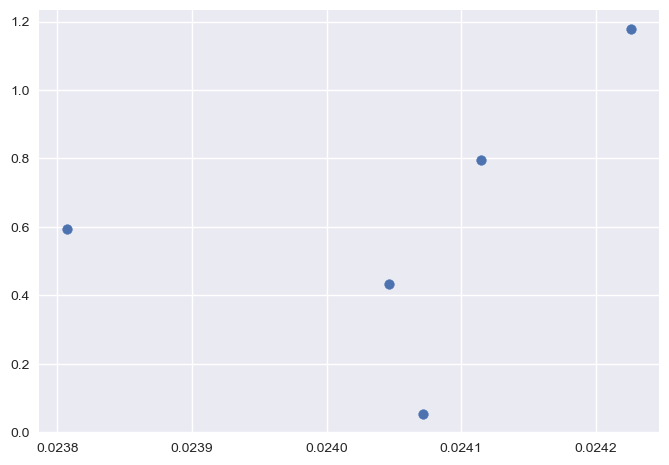

In [241]:
X=ridership_quality_combined_nonzero[quality_variable_columns]
Y=ridership_quality_combined_nonzero['pct_change']
plt.scatter(X['accessible_alpha_lts1'],Y)

## 5. Scatter plot: betweenness centrality vs. bike commute share

This plot shows each tract's mean bike-network centrality against the percentage of workers commuting by bicycle.

In [ ]:
# fig, ax = plt.subplots(figsize=(10, 6))
# for year, group in tracts.groupby("year"):
#     group = group.dropna(subset=["betweenness", "pct_bike"])
#     ax.scatter(
#         group["betweenness"],
#         group["pct_bike"],
#         alpha=0.75,
#         s=60,
#         label=str(year)
#     )

# ax.set_xlabel("Mean Bike-Network Betweenness Centrality (tract)")
# ax.set_ylabel("% Workers Commuting by Bicycle")
# ax.set_title("Berkeley Census Tracts: Bike Commute Share vs. Bike Network Betweenness")
# ax.legend(title="ACS Year")
# ax.grid(True, linestyle=':', alpha=0.5)
# plt.tight_layout()
# plt.show()

In [22]:
range = len(group.dropna(subset=["pct_bike"]))

NameError: name 'group' is not defined

Replace QUALITY_METRIC with correct label

KeyError: ['QUALITY_METRIC']

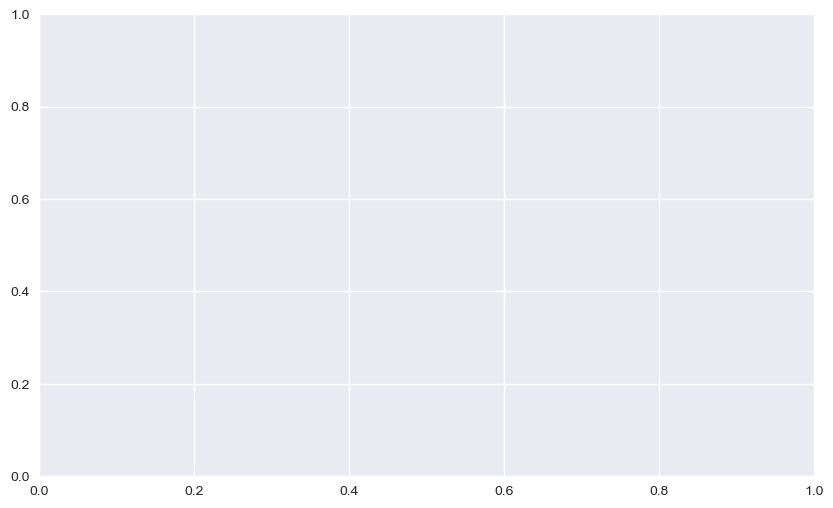

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
for year, group in tracts.groupby("year"):
    group = group.dropna(subset=["QUALITY_METRIC", "pct_bike"])
    ax.scatter(
        group["QUALITY_METRIC"],
        group["pct_bike"],
        alpha=0.75,
        s=60,
        label=str(year)
    )

ax.set_xlabel("Bike Network Quality (LCC for LTS < 2 subnetwork)")
ax.set_ylabel("% Workers Commuting by Bicycle")
ax.set_title("Berkeley Census Tracts: Bike Commute Share vs. Bike Network Quality")
ax.legend(title="ACS Year")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()